# Informações:
- Precisão de 67%
- Matriz de confusão com diagonal principal destacada
- ResNet34
- Fine tuning na melhor faixa de aprendizado identificada pelo lr_find()
- Gráfico lr_find()

Tentar: aplicar peso para que todas as classes tenham o mesmo impacto no treinamento e resolver problema de reprodutibilidade (toda vez que roda da um resultado diferente)

# Instruções

Para executar os códigos abaixo com mais rapidez:

1. Clique no ▾ do lado de "Conectar".

2. Alterar o tipo de ambiente de execução

3. Acelerador de hardware: GPU T4

# Importação e Visualização dos Dados

#1 - Download e extração dos dados

In [ ]:
# Baixa o arquivo zip direto do repositório do GitHub
!wget https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip

# Extrai os arquivos silenciosamente (-q) para não poluir a tela
!unzip -q 2020-02-14_InfraredSolarModules.zip

# Mostra o que foi extraído na pasta atual
!ls

--2026-06-22 19:17:26--  https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/RaptorMaps/InfraredSolarModules/master/2020-02-14_InfraredSolarModules.zip [following]
--2026-06-22 19:17:26--  https://raw.githubusercontent.com/RaptorMaps/InfraredSolarModules/master/2020-02-14_InfraredSolarModules.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15495990 (15M) [application/zip]
Saving to: ‘2020-02-14_InfraredSolarModules.zip’

2020-02-14_Infrared 100%[===================>]  14.78M  --.-KB/s    in 0.09s   

#2 - Leitura do JSON e criação do mapeamento

In [ ]:
import json
import pandas as pd
import cv2
from matplotlib import pyplot as plt

# Abre e lê o arquivo JSON
with open('InfraredSolarModules/module_metadata.json', 'r') as f:
    metadados = json.load(f)

# Converte o JSON para um DataFrame do Pandas
df = pd.DataFrame.from_dict(metadados, orient='index')

# Consolidação de redundâncias
substituicoes = {
    'Cell-Multi': 'Cell',
    'Diode-Multi': 'Diode',
    'Hot-Spot-Multi': 'Hot-Spot'
}
df['anomaly_class'] = df['anomaly_class'].replace(substituicoes)

# Separa dataset em dois grupos
df_no_anomaly = df[df['anomaly_class'] == 'No-Anomaly']
df_anomalias = df[df['anomaly_class'] != 'No-Anomaly']

# Reduz classe 'No-Anomaly' para 1800 imagens
df_no_anomaly_reduzido = df_no_anomaly.sample(n=1800, random_state=42)

# Une os dois datasets e embaralha
df_balanceado = pd.concat([df_no_anomaly_reduzido, df_anomalias])
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)
df = df_balanceado

# Mostra as primeiras 5 linhas e a conagem das classes
print(df.head())
print("\n--- CONTAGEM DE CLASSES ---")
print(df['anomaly_class'].value_counts())

     image_filepath anomaly_class
0   images/4796.jpg          Cell
1  images/12302.jpg    No-Anomaly
2   images/8974.jpg    Vegetation
3   images/1484.jpg         Diode
4   images/8996.jpg    Vegetation

--- CONTAGEM DE CLASSES ---
anomaly_class
Cell              3165
No-Anomaly        1800
Diode             1674
Vegetation        1639
Shadowing         1056
Cracking           940
Offline-Module     827
Hot-Spot           495
Soiling            204
Name: count, dtype: int64


# Processamento de Imagens com Deep Learning

# 3 - Preparação dos Dados

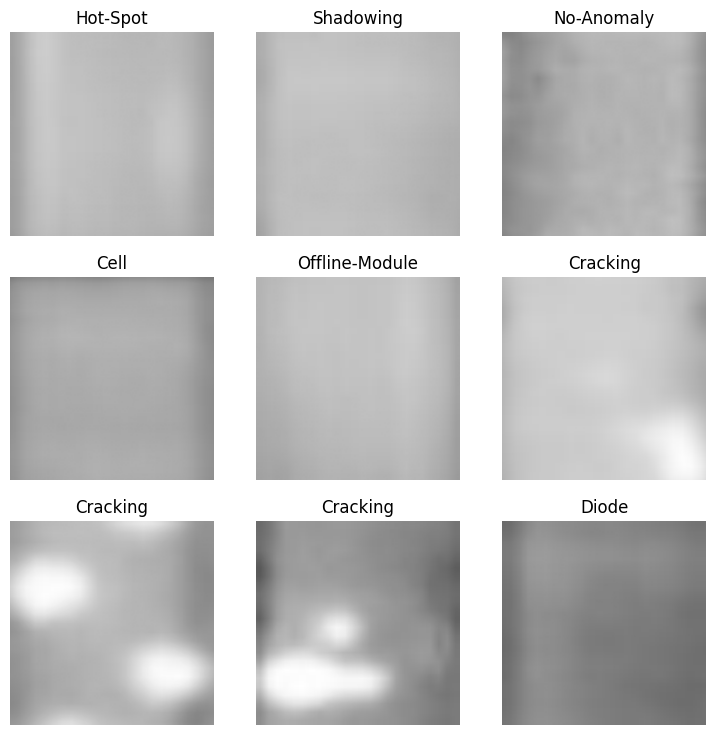

In [ ]:
# Instala o fast.ai no ambiente do Colab
!pip install -U fastai -q
from fastai.vision.all import *
set_seed(42, reproducible=True)

# Cria os DataLoaders
dls = ImageDataLoaders.from_df(
    df,
    path='InfraredSolarModules',
    fn_col='image_filepath',
    label_col='anomaly_class',
    item_tfms=Resize(224),
    #batch_tfms=aug_transforms()  # Aplica rotações e brilho automáticos
    batch_tfms=aug_transforms(do_flip=True, max_rotate=0.0, max_lighting=0.0, max_warp=0.0)
)

# Exibe as imagens processadas
dls.show_batch()

# 4 - Treinamento

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 132MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,2.586469,1.761448,0.397034,00:44
1,1.937005,1.495239,0.488983,00:40
2,1.661774,1.368305,0.513559,00:44
3,1.549610,1.348932,0.520763,00:46


<div></div>

SuggestedLRs(valley=5.248074739938602e-05)

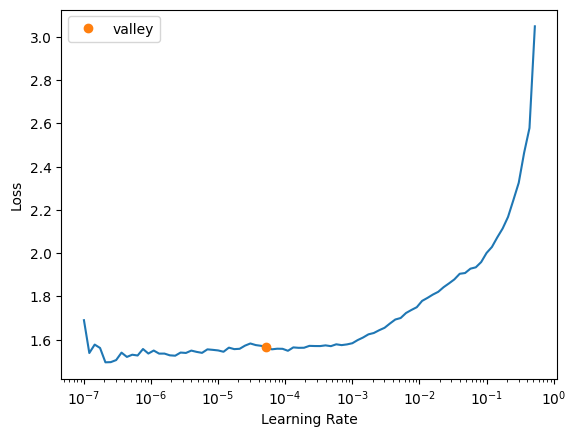

In [ ]:
# Treinamento inicial com ResNet34
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fit_one_cycle(4)

# Salva pesos
learn.save('modelo-resnet34-etapa1')

# Execura lr_find para encontrar a melhor faixa de aprendizado para o fine tuning
learn.unfreeze()
learn.lr_find()

In [ ]:
# Treina na faixa de aprendizado selecionada do gráfico (fine tuning)
taxa_min = 1e-5
taxa_max = 1e-3

learn.load('modelo-resnet34-etapa1')

learn.unfreeze()
learn.fit_one_cycle(10, lr_max=slice(taxa_min, taxa_max))

epoch,train_loss,valid_loss,accuracy,time
0,1.489884,1.272103,0.532203,01:03
1,1.437138,1.229546,0.558475,01:01
2,1.291440,1.137365,0.577119,01:01
3,1.211342,1.092431,0.594492,01:01
4,1.109182,1.054259,0.612712,01:01
5,1.046458,1.015745,0.629237,01:01
6,0.996383,0.950150,0.651271,01:00
7,0.912423,0.938218,0.661017,01:00
8,0.855086,0.916896,0.667373,01:01
9,0.814265,0.917797,0.668220,01:01


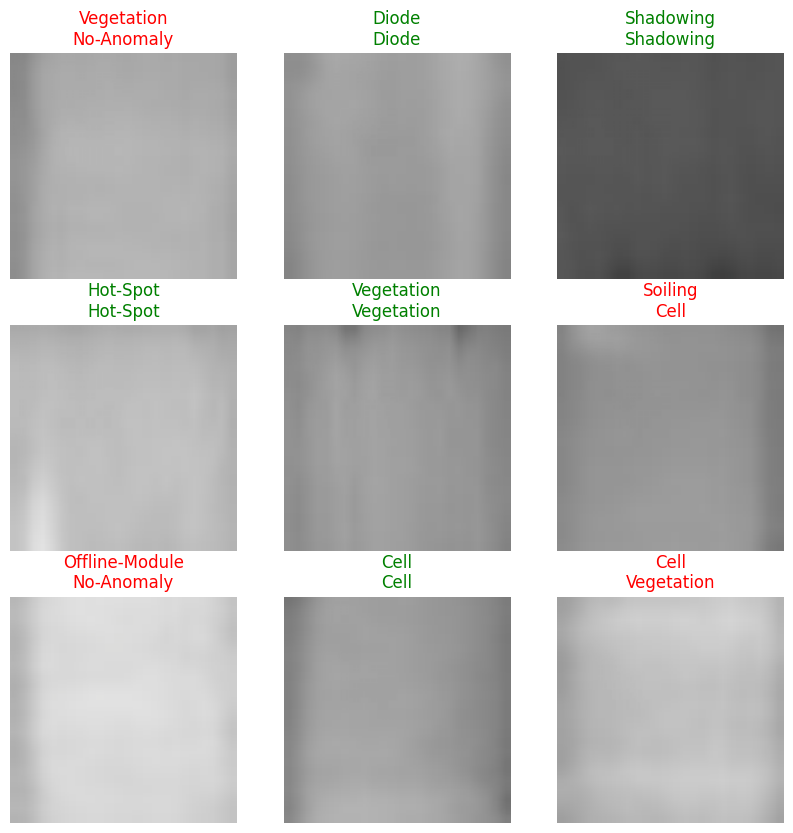

In [ ]:
# Mostra os resultados visuais: a classe verdadeira vs. a previsão do modelo
learn.show_results(max_n=9, figsize=(10, 10))

# 5 - Matriz de Confusão

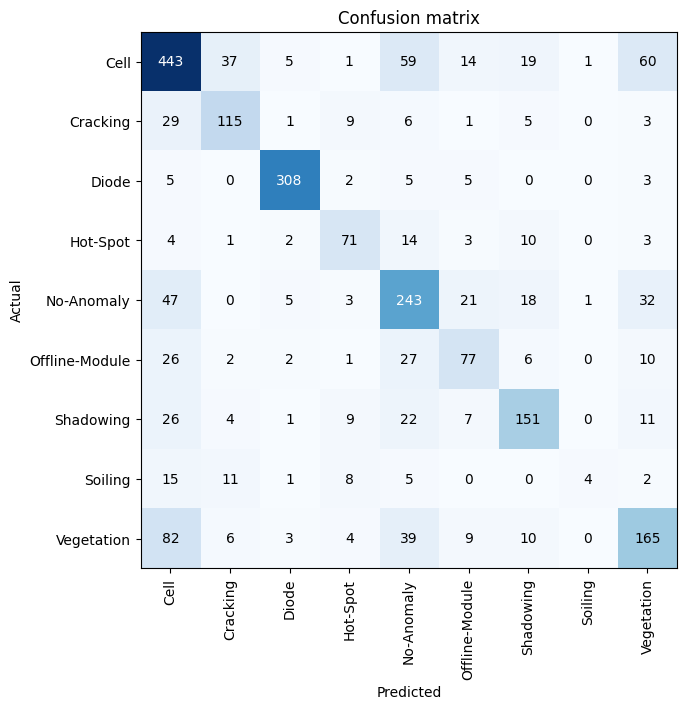

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)

# Plota a matriz de confusão para as 4 classes
interp.plot_confusion_matrix(figsize=(7, 7))

# 6 - Top Losses
Diagnóstico visual de onde a rede errou estando convicta de que estava certa

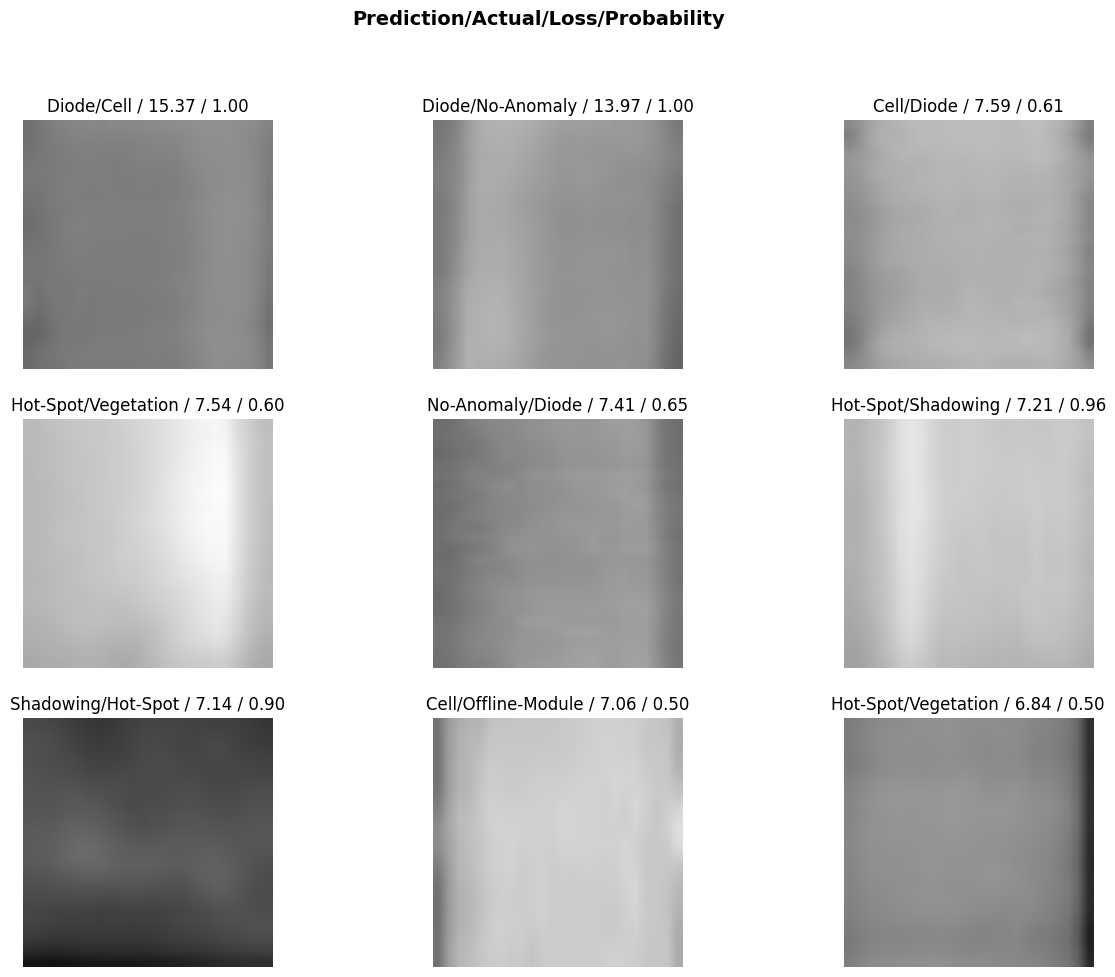

In [ ]:
# Cria o objeto de interpretação
interp = ClassificationInterpretation.from_learner(learn)

# Plota as imagens com os maiores erros (Top Losses)
interp.plot_top_losses(k=9, figsize=(15, 11))

# Exporta o modelo final completo (arquitetura + pesos)
# Isso cria um arquivo 'modelo_termografico_final.pkl' que você pode usar depois para fazer inferências em tempo real ou num aplicativo.
learn.export('modelo_termografico_final.pkl')